In [1]:
import torch
from torch import nn
import numpy as np

In [2]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

In [3]:
image_path

PosixPath('data/desert101')

In [4]:
import os

In [5]:
# Datamızı kontrol etmek için bir fonksiyon yazdık.
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories :{len(dirnames)} and {len(filenames)} images in {dirpath}")

In [6]:
check_data(image_path)

# of directories :2 and 1 images in data/desert101
# of directories :4 and 1 images in data/desert101/test
# of directories :0 and 20 images in data/desert101/test/cup_cakes
# of directories :0 and 20 images in data/desert101/test/donuts
# of directories :0 and 20 images in data/desert101/test/baklava
# of directories :0 and 20 images in data/desert101/test/cannoli
# of directories :4 and 1 images in data/desert101/train
# of directories :0 and 80 images in data/desert101/train/cup_cakes
# of directories :0 and 80 images in data/desert101/train/donuts
# of directories :0 and 80 images in data/desert101/train/baklava
# of directories :0 and 80 images in data/desert101/train/cannoli


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [8]:
train_dir

PosixPath('data/desert101/train')

In [9]:
test_dir

PosixPath('data/desert101/test')

In [10]:
from PIL import Image
import random

In [11]:
random.seed(12)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image = random.choice(image_path_list)
img = Image.open(random_image)

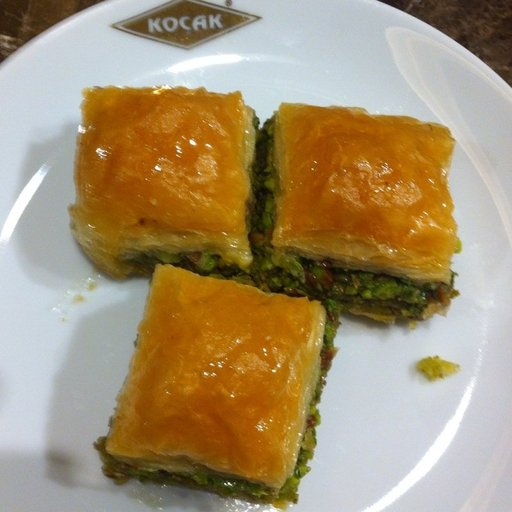

In [12]:
img

In [13]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [14]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

In [15]:
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform)
test_data  = datasets.ImageFolder(root=test_dir, transform=data_transform)

In [16]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [17]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data/desert101/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [30]:
class_names = train_data.classes
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [19]:
len(train_data), len(test_data)

(316, 77)

In [20]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() # İşlemcinin çekirdekleri

In [21]:
NUM_WORKERS

16

In [22]:
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_datalaoder  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [23]:
train_dataloader.dataset[0][0]

tensor([[[0.6000, 0.5922, 0.5333,  ..., 0.4784, 0.4510, 0.4549],
         [0.6431, 0.5529, 0.5098,  ..., 0.5294, 0.4471, 0.4706],
         [0.6863, 0.5412, 0.5608,  ..., 0.5843, 0.4667, 0.5490],
         ...,
         [0.0510, 0.0314, 0.0196,  ..., 0.1647, 0.1804, 0.2000],
         [0.0549, 0.0196, 0.0118,  ..., 0.2078, 0.1961, 0.1804],
         [0.0627, 0.0392, 0.0471,  ..., 0.1686, 0.1490, 0.1804]],

        [[0.4824, 0.4784, 0.4196,  ..., 0.3451, 0.3137, 0.3216],
         [0.5294, 0.4471, 0.4000,  ..., 0.4078, 0.3333, 0.3569],
         [0.5725, 0.4353, 0.4392,  ..., 0.4549, 0.3412, 0.4078],
         ...,
         [0.7098, 0.2314, 0.1804,  ..., 0.5961, 0.5725, 0.5451],
         [0.7216, 0.1882, 0.1725,  ..., 0.5569, 0.5686, 0.5765],
         [0.7098, 0.7647, 0.7647,  ..., 0.6314, 0.6431, 0.6000]],

        [[0.2118, 0.2157, 0.1686,  ..., 0.0980, 0.0824, 0.0902],
         [0.2314, 0.1804, 0.1490,  ..., 0.1490, 0.1020, 0.1137],
         [0.2510, 0.1725, 0.1529,  ..., 0.1765, 0.1059, 0.

In [29]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape:int, hidden_unit:int, output_layer:int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(in_channels=hidden_unit, out_channels=hidden_unit, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.dense_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_unit *16*16, out_features=output_layer)
        )
    def forward(self,x):
        out = self.conv_block_1(x)
        out = self.conv_block_2(out)
        out = self.dense_layer(out)
        return out

In [31]:
model_0 = DesertClassifier(
    input_shape=3,
    hidden_unit=32,
    output_layer=len(class_names)
)

In [33]:
from torchinfo import summary

In [34]:
summary(model= model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─GELU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─GELU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─GELU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─GELU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [35]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer
              ):
    
    model.train() # Modelimizi train moduna alıyoruz.
    
    train_loss = 0 # Train Loss değerlerini tutmak için bir değişken oluşturuyoruz.
    train_acc = 0 # Train Accuracy değerlerini tutmak için bir değişken oluşturuyoruz.

    for batch, (X,y) in enumerate(dataloader): # Batch size gerekli değil burada.
        y_pred = model(X) # Modelimize bir tahminde bulunduruyoruz.
        
        loss = loss_fn(y_pred,y) # Loss değerlerimizi loss_fn ile hesaplıyoruz.
        train_loss += loss.item() # Çıkan loss değerlerini train_loss değişlenine toplayarak atıyoruz.

        # Modelimizi backpropagation yapıyoruz.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Softmax kullanarak modelimize label tahmininde bulunduruyoruz.
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1) 
        
        train_acc += (y_pred_class == y).sum().item() / len(y_pred) # Train 

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

In [39]:
def test_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module
              ):
    
    model.eval() # Modelimizi test moduna alıyoruz.
    
    test_loss = 0 # test loss'ları tutmak için bir değişken oluşturuyoruz.
    test_acc = 0 # test accuracy'ları tutmak için bir değişken oluşturuyoruz.
    
    with torch.inference_mode(): # inference mode'a aldık.
        for batch, (X,y) in enumerate(dataloader): # batch gerekli değil fakat yine de aldık.
            test_pred = model(X) # modelimize tahmin ettiriyoruz.
            
            loss = loss_fn(test_pred,y) # loss'umuzu loss_fn ile hesaplıyoruz.
            test_loss += loss.item() # loss değerlerimizi test_loss değişkeninde topluyoruz.

            # Softmax activation function ile label tahmin ettiriyoruz.
            test_pred_label = torch.softmax(test_pred,dim=1).argmax(dim=1) 
            
            acc = (test_pred_label == y).sum().item() / len(test_pred) # Calculate accuracy
            test_acc += acc # Accuracy değerlerimizi toplayıp test_acc değişkenine atıyoruz.
            
    test_loss /= len(dataloader) # Test loss değerlerimizi dataloader boyuna bölüyoruz.
    test_acc /= len(dataloader) # Test acc değerlerimizi dataloader boyuna bölüyoruz.
    
    return test_loss, test_acc # Geriye test_loss ve test_acc döndürüyoruz.